# AIoT Project

This notebook is the entry point for the analysis pipeline. It assumes the PAMAP2 dataset has already been parsed and ingested into MongoDB by `aiot_dataset_creation_sample.ipynb` — every cell below should fetch its inputs from the MongoDB collection, **not** from the raw `.dat` files.

In [193]:
import os
import sys

# Set random seeds for reproducibility
import random
import numpy as np
np.random.seed(42)
random.seed(42)

# basic data engineering
import pandas as pd
pd.options.mode.copy_on_write = True
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time
import logging

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [194]:
time_start = time()

## Load configuration

In [195]:
config_path = os.path.join(os.getcwd(), "config.yml")

if not os.path.exists(config_path):
    logger.error(f"Config file not found at {config_path}")
    logger.info("Copy config.yml.template to config.yml and fill in your settings")
    raise FileNotFoundError(config_path)

try:
    with open(config_path) as file:
        config = yaml.load(file, Loader=yaml.FullLoader)
    logger.info(f"Configuration loaded successfully from {config_path}")
except yaml.YAMLError as e:
    logger.error(f"Failed to parse config.yml: {e}")
    raise

# Validate required config keys
required_keys = ["client", "db", "col", "sliding_window", "filter", "classifier", "fine_tune"]
missing_keys = [key for key in required_keys if key not in config]
if missing_keys:
    logger.error(f"Missing required config keys: {missing_keys}")
    raise KeyError(f"Config missing keys: {missing_keys}")

logger.info("Configuration validation passed")

2026-04-30 02:31:40,602 - INFO - Configuration loaded successfully from /home/manousos_kirkinis/Desktop/Projects/AIIoT-Semester-Project/config.yml
2026-04-30 02:31:40,602 - INFO - Configuration validation passed


In [196]:
try:
    client = pymongo.MongoClient(config["client"], serverSelectionTimeoutMS=5000)
    # Verify connection
    client.admin.command("ping")
    logger.info(f"✓ Connected to MongoDB at {config['client']}")
except pymongo.errors.ConnectionFailure as e:
    logger.error(f"✗ Failed to connect to MongoDB: {e}")
    logger.info("Ensure MongoDB is running: mongod or mongodump service")
    raise
except Exception as e:
    logger.error(f"✗ Unexpected error connecting to MongoDB: {e}")
    raise

2026-04-30 02:31:40,620 - INFO - ✓ Connected to MongoDB at mongodb://localhost:27017/


In [197]:
db = client[config["db"]]
coll = db[config["col"]]

## Load data

Fetch the documents that correspond to the **sensor configuration you are evaluating**. Start with the hand/wrist IMU in the AccGyr configuration (the default), e.g.:

```python
query = {"imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))
```

Carry the `subject` field through every transformation (windowing, filtering, feature extraction) — you will need it for the **subject-disjoint** train/test split below.

When you later expand to chest/ankle IMUs, change the query and re-run the pipeline so you can compare the per-configuration results in your report.

In [198]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


In [199]:
query = {"imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))

In [200]:
print(f"Loaded documents: {len(documents)}")

if len(documents) > 0:
    example = documents[0]
    print("Example document keys:", sorted(example.keys()))
    print("Example sensor/imu_location/subject:", example.get("sensor"), example.get("imu_location"), example.get("subject"))

segments_df = pd.DataFrame([
    {
        "activity_label": doc["activity_label"],
        "activity_id": doc["activity_id"],
        "subject": doc["subject"],
        "imu_location": doc["imu_location"],
        "sensor": doc["sensor"],
        "segment_length": len(doc["data"]["acc_x"]),
        "sr": doc.get("sr", 100),
    }
    for doc in documents
])
segments_df["duration_sec"] = segments_df["segment_length"] / segments_df["sr"]
segments_df.head()

Loaded documents: 30244
Example document keys: ['_id', 'activity_id', 'activity_label', 'data', 'datetime', 'imu_location', 'sensor', 'split', 'sr', 'subject']
Example sensor/imu_location/subject: AccGyr hand 101


,activity_label,activity_id,subject,imu_location,sensor,segment_length,sr,duration_sec
0,lying,1,101,hand,AccGyr,128,100,1.28
1,lying,1,101,hand,AccGyr,128,100,1.28
2,lying,1,101,hand,AccGyr,128,100,1.28
3,lying,1,101,hand,AccGyr,128,100,1.28
4,lying,1,101,hand,AccGyr,128,100,1.28


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

/tmp/ipykernel_49547/2360478576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_duration.index, y=activity_duration.values, palette="viridis")


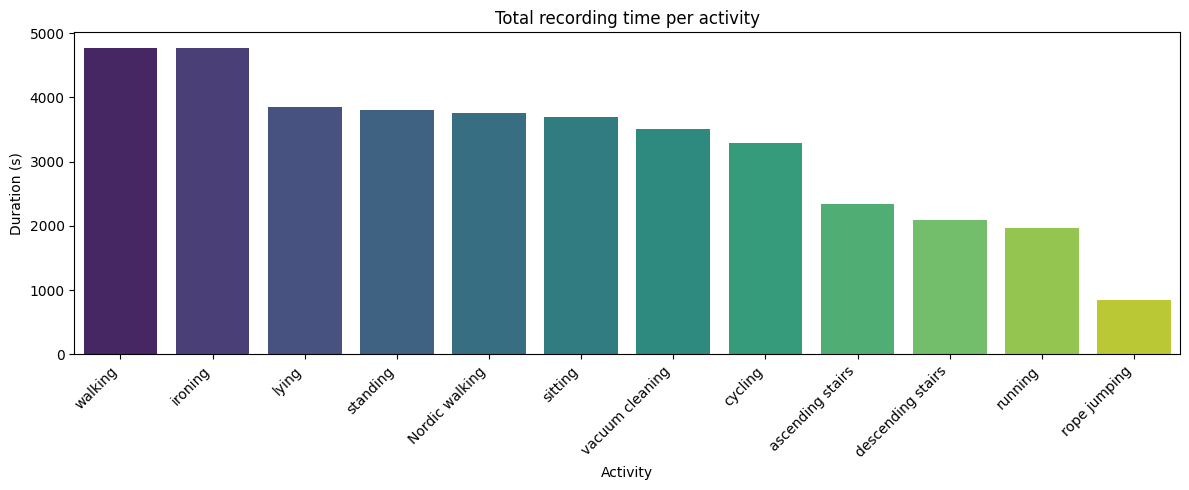

In [201]:
# Total recording time per activity 

activity_duration = segments_df.groupby("activity_label")["duration_sec"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=activity_duration.index, y=activity_duration.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Total recording time per activity")
plt.ylabel("Duration (s)")
plt.xlabel("Activity")
plt.tight_layout()

/tmp/ipykernel_49547/2608201324.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(16, 6))


<Figure size 1600x600 with 0 Axes>

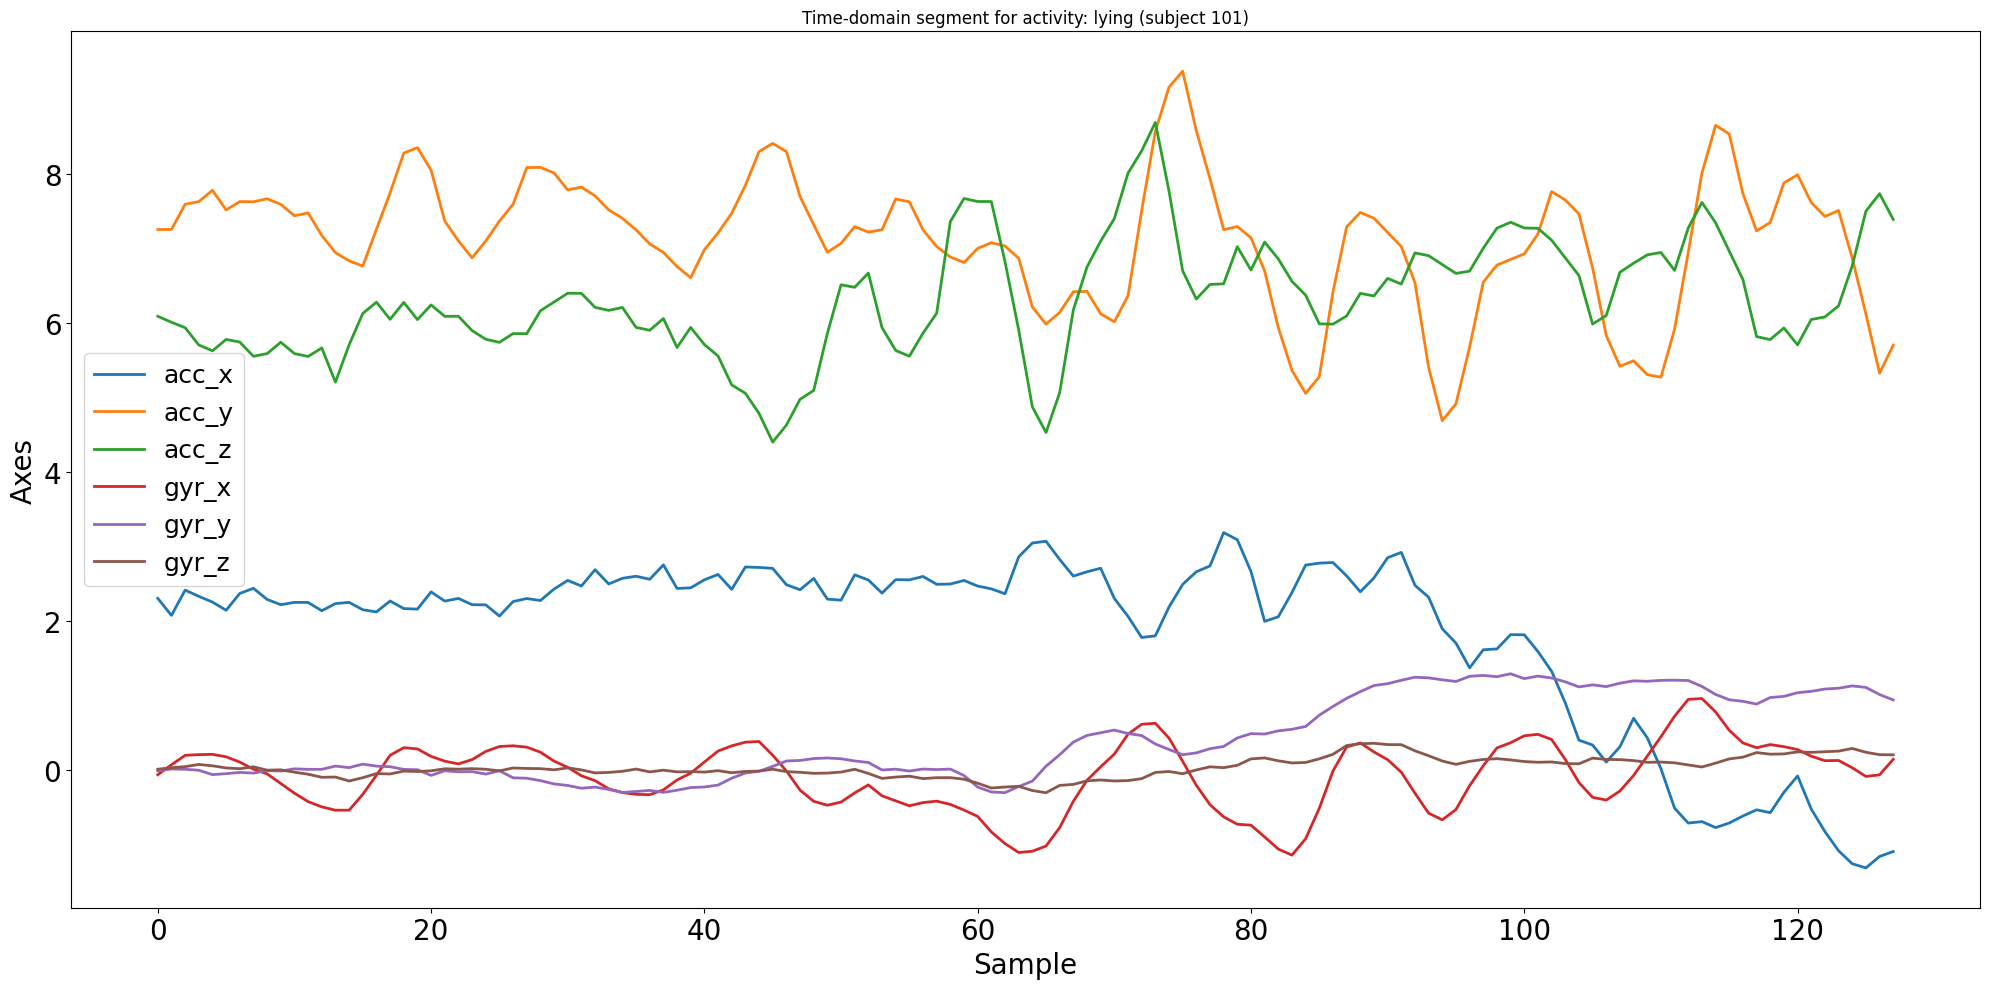

<Figure size 1600x600 with 0 Axes>

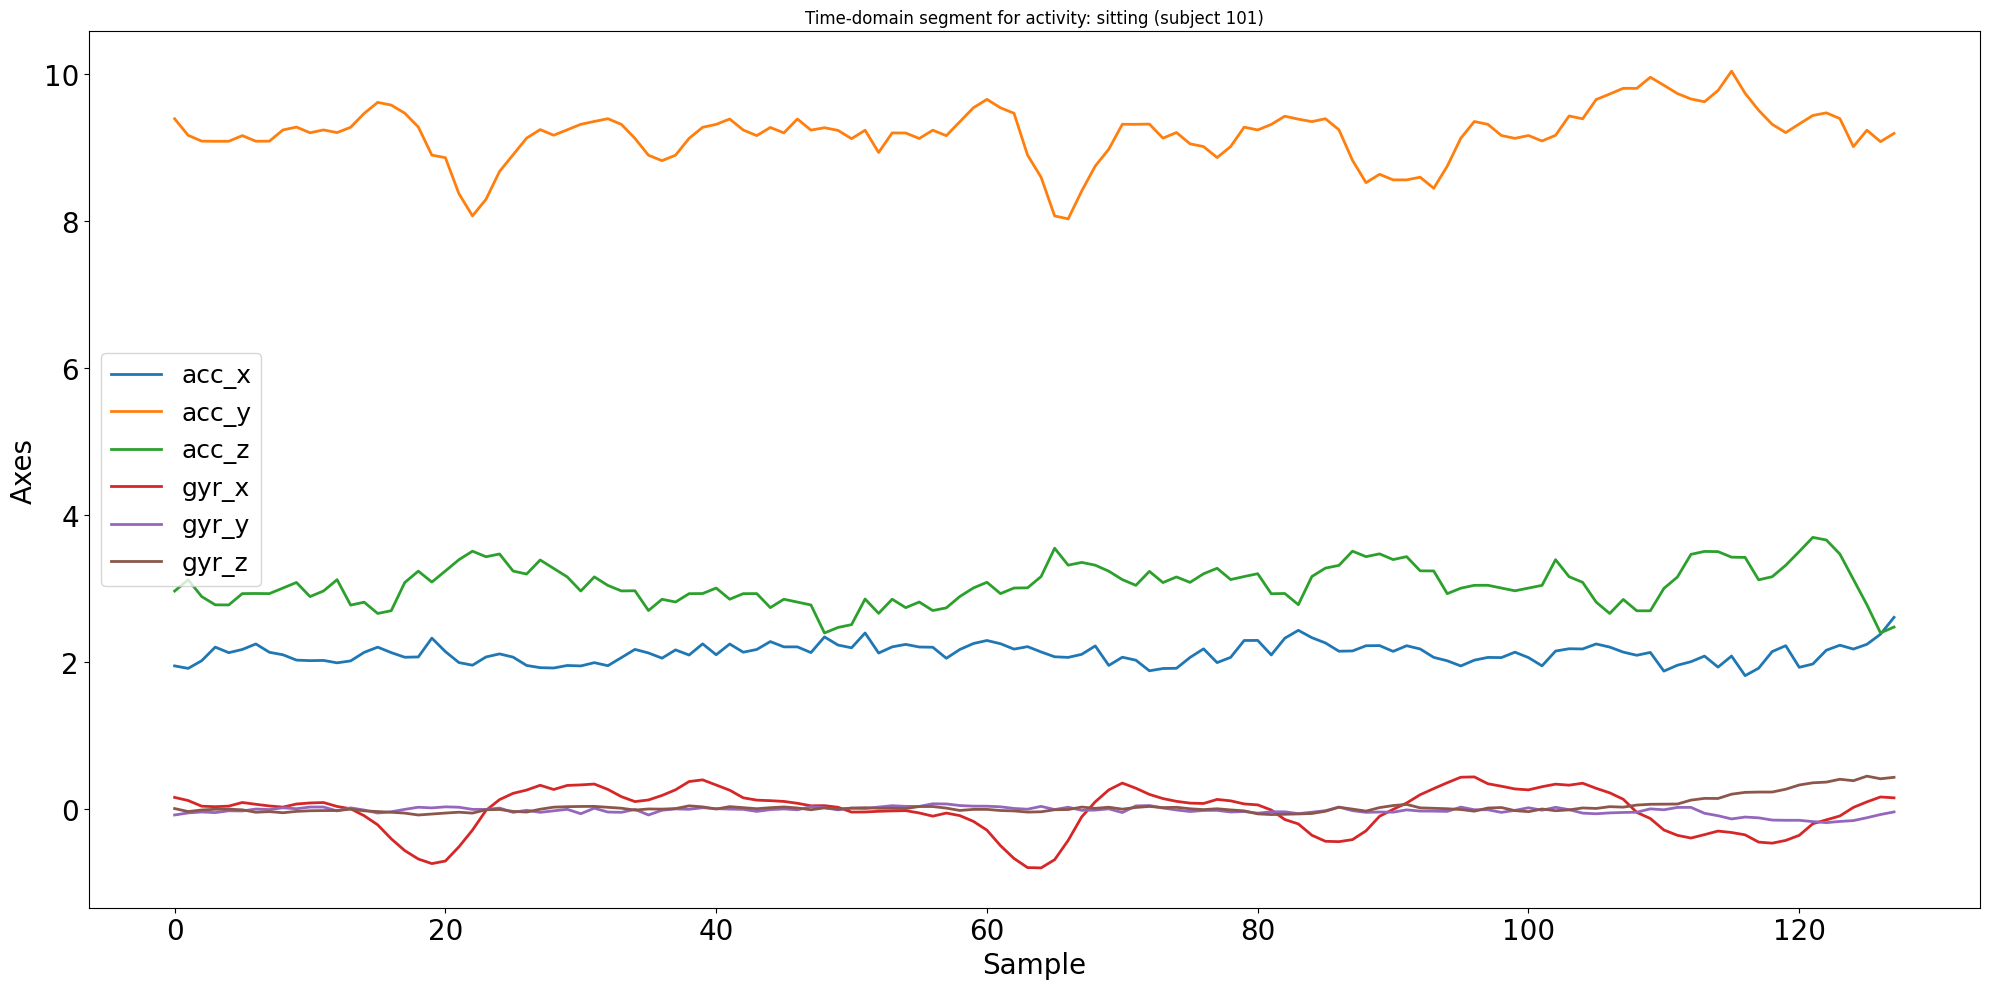

<Figure size 1600x600 with 0 Axes>

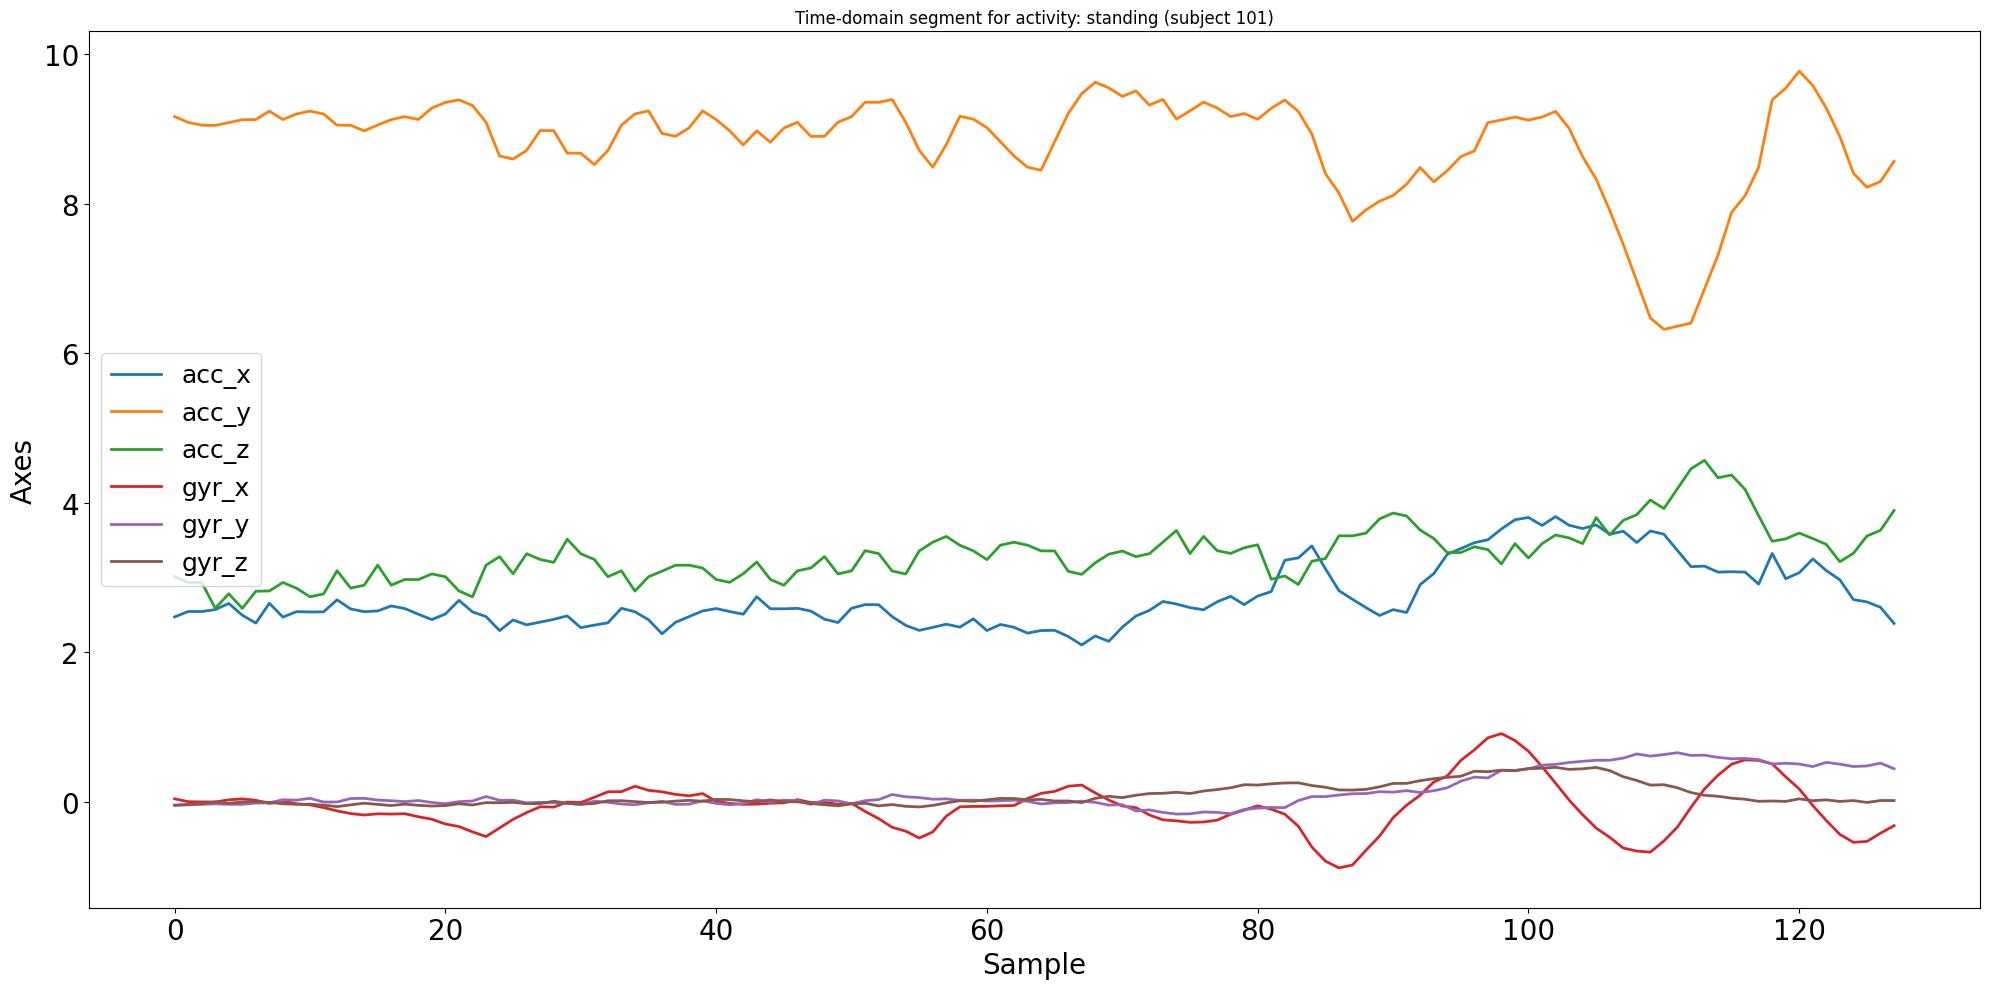

<Figure size 1600x600 with 0 Axes>

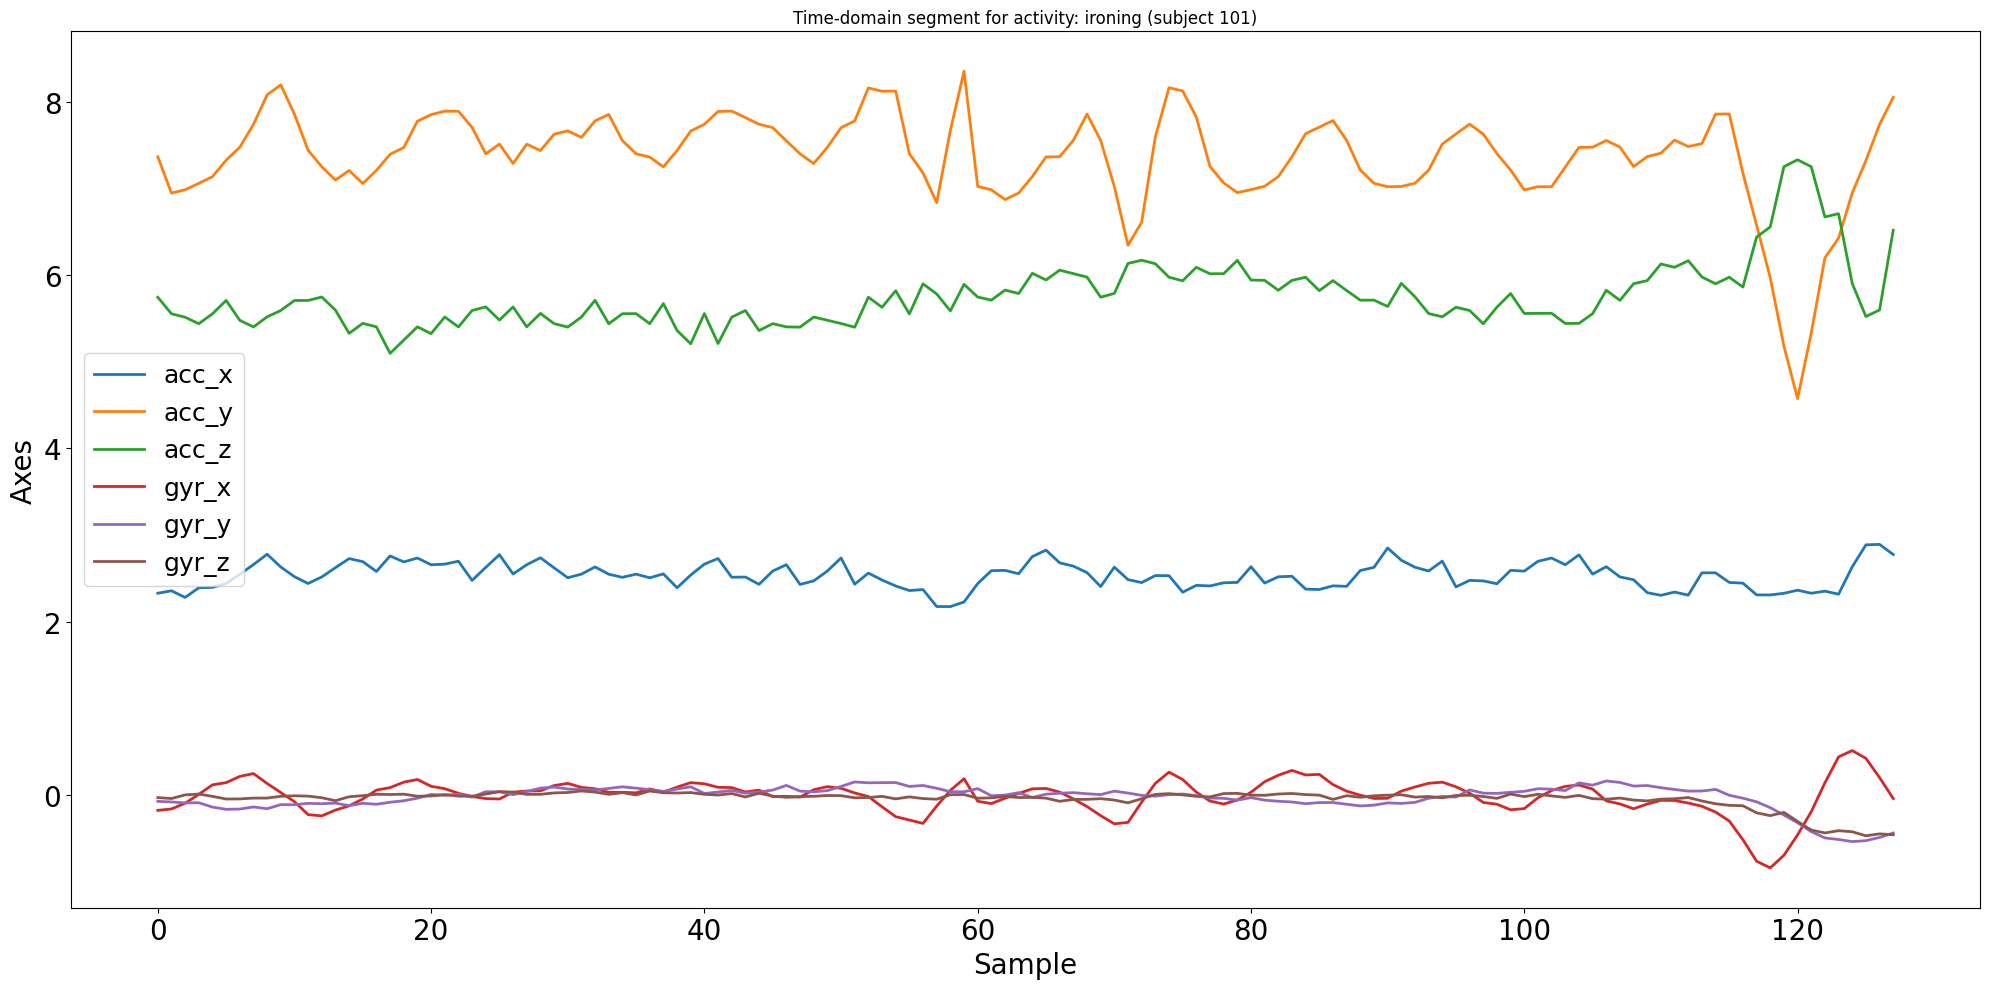

<Figure size 1600x600 with 0 Axes>

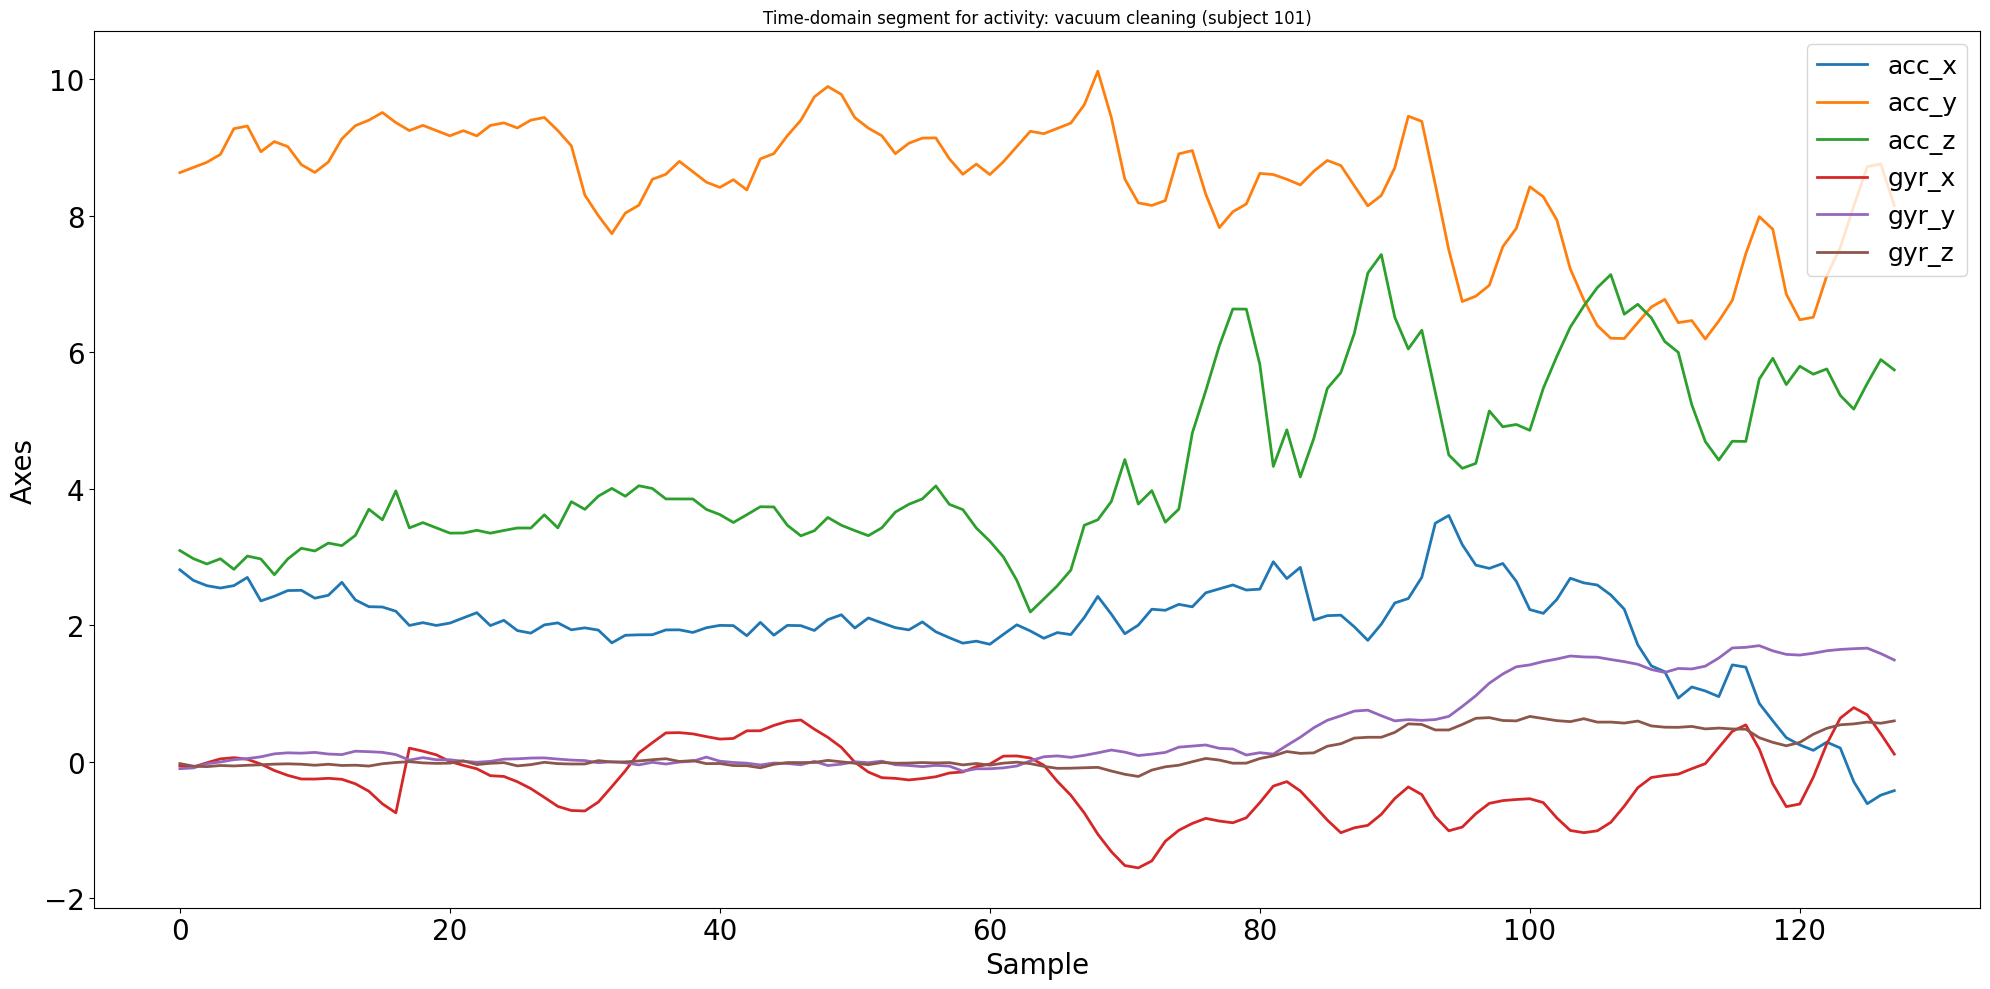

<Figure size 1600x600 with 0 Axes>

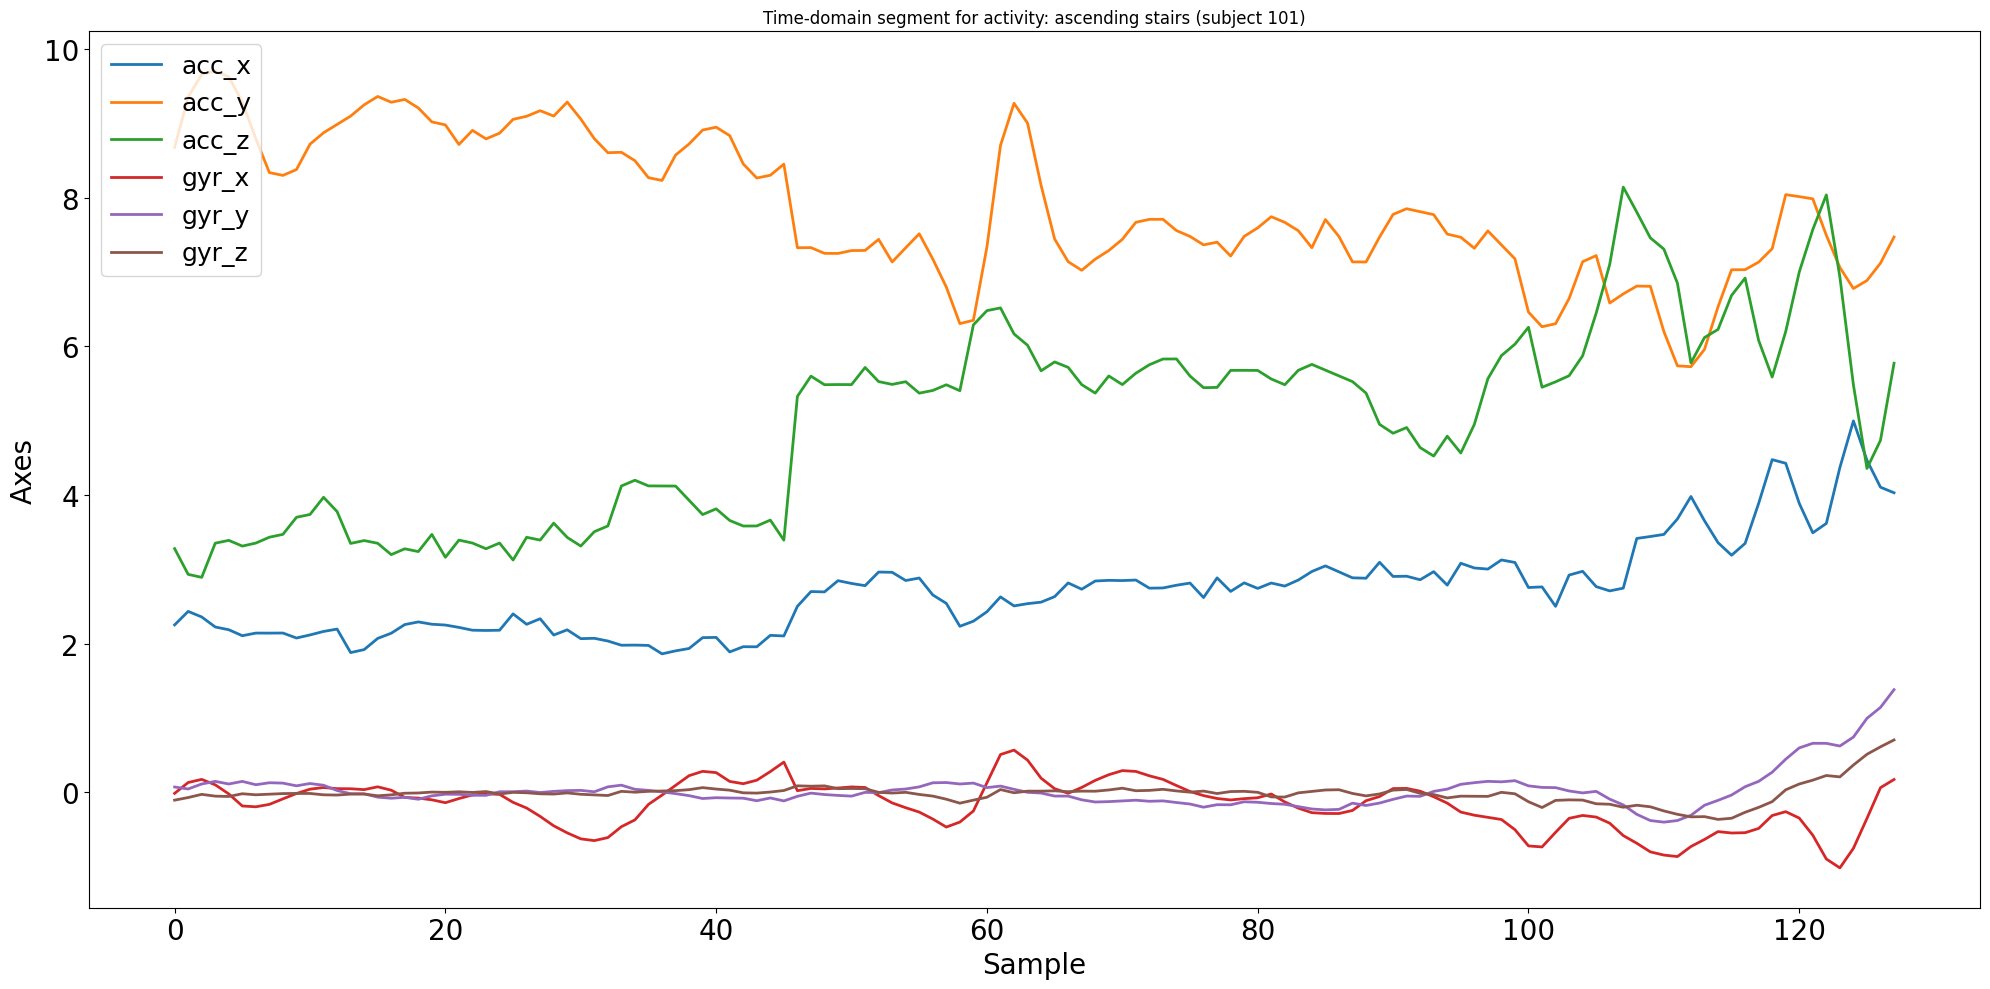

<Figure size 1600x600 with 0 Axes>

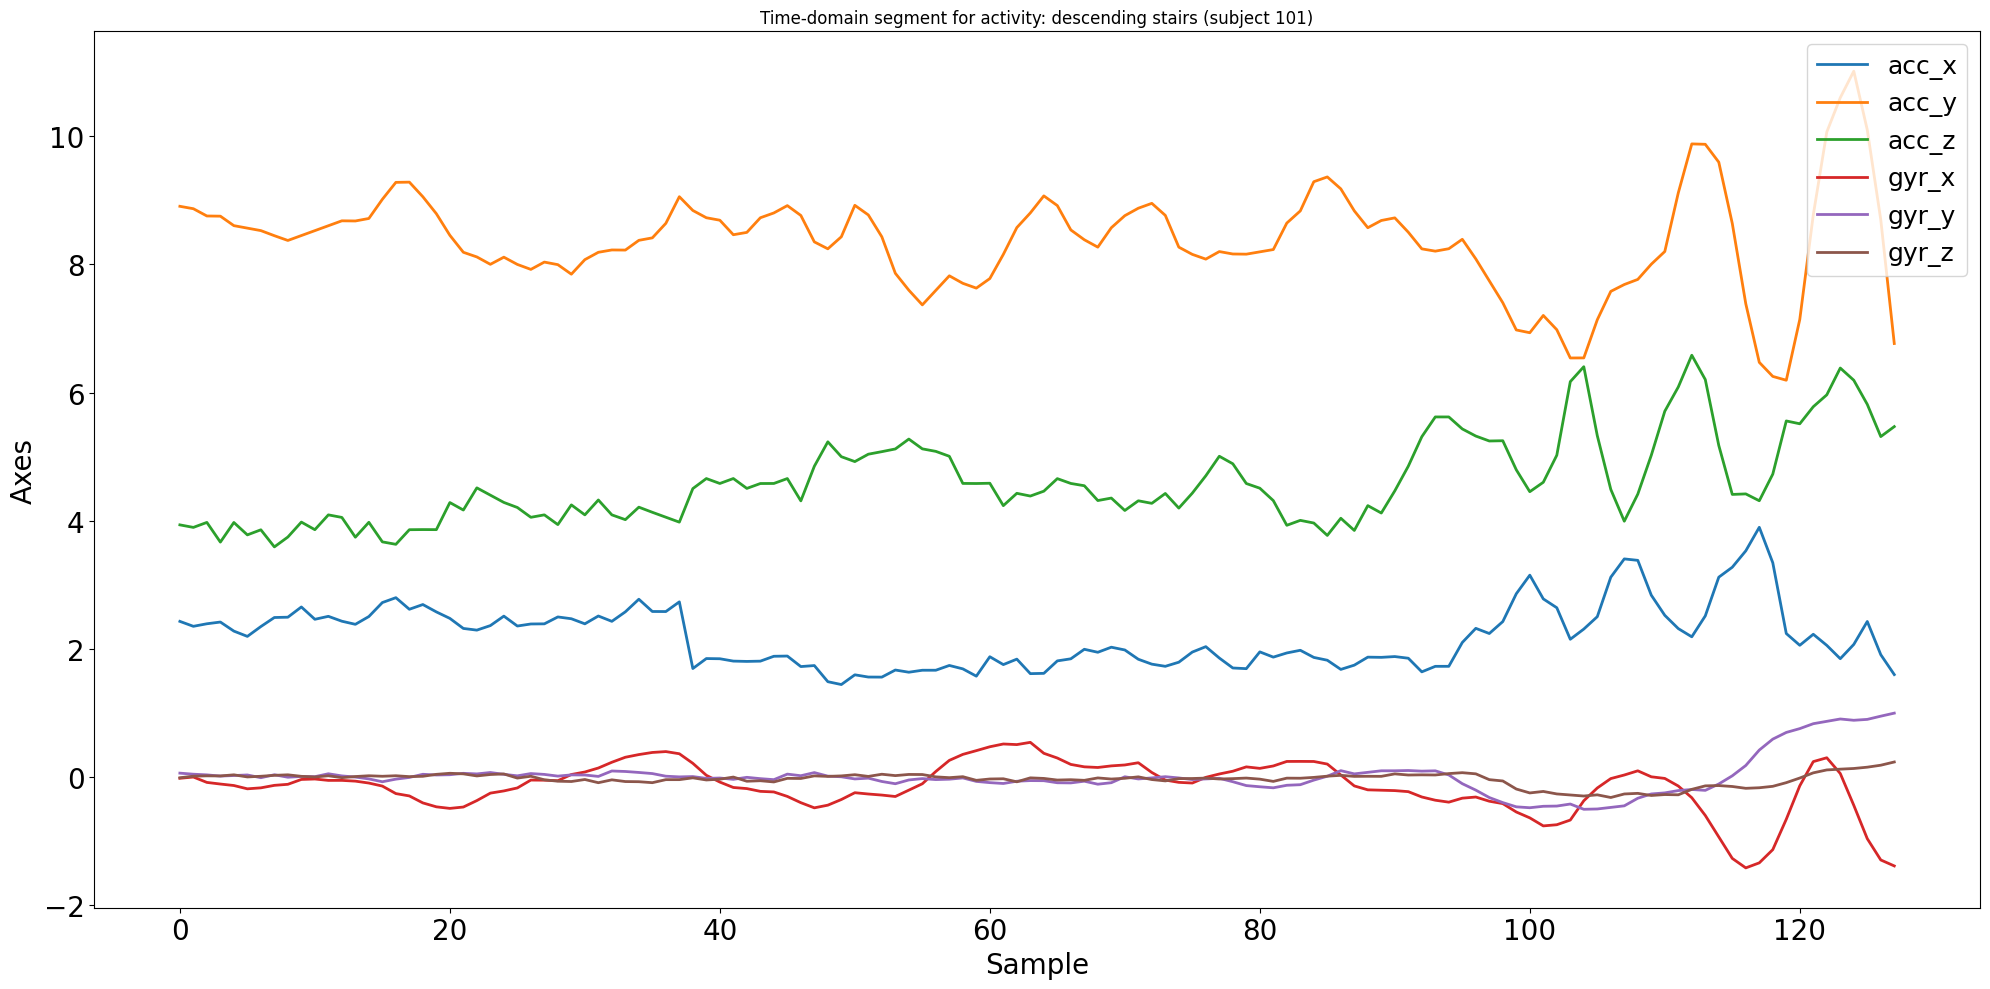

<Figure size 1600x600 with 0 Axes>

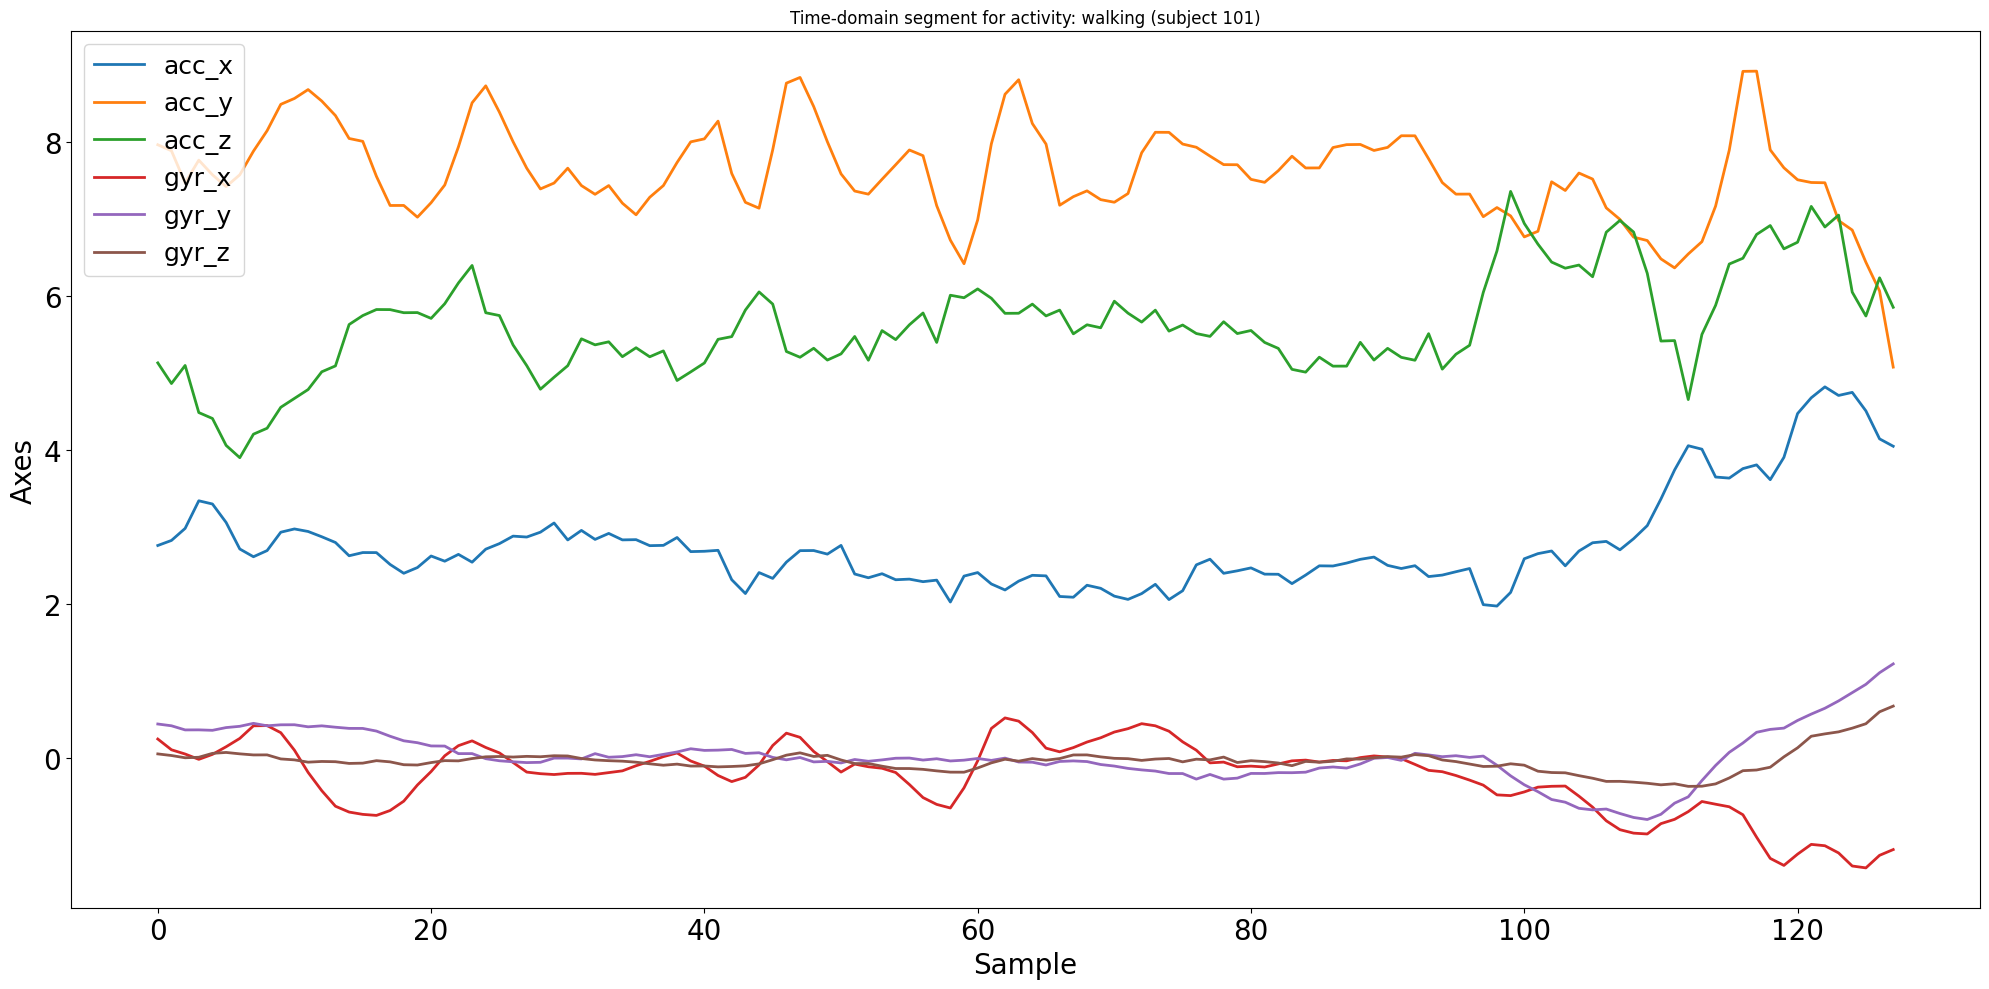

<Figure size 1600x600 with 0 Axes>

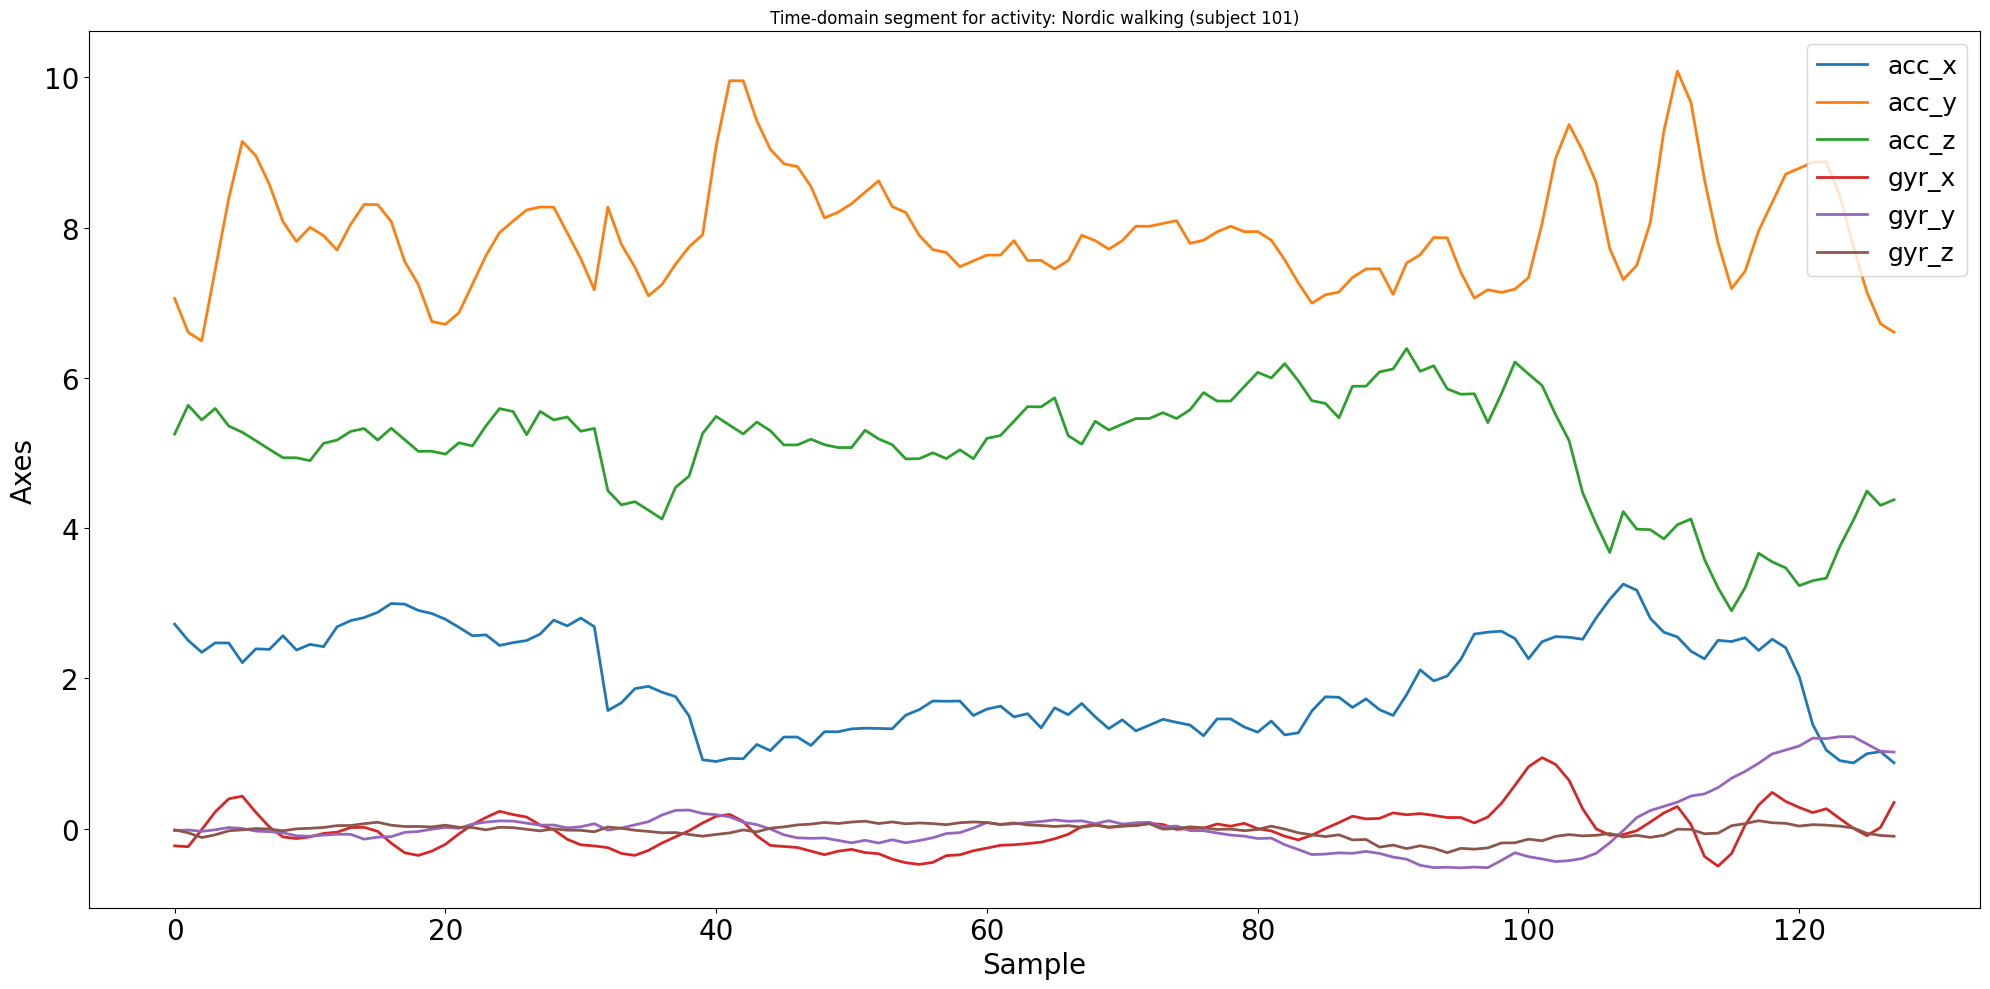

<Figure size 1600x600 with 0 Axes>

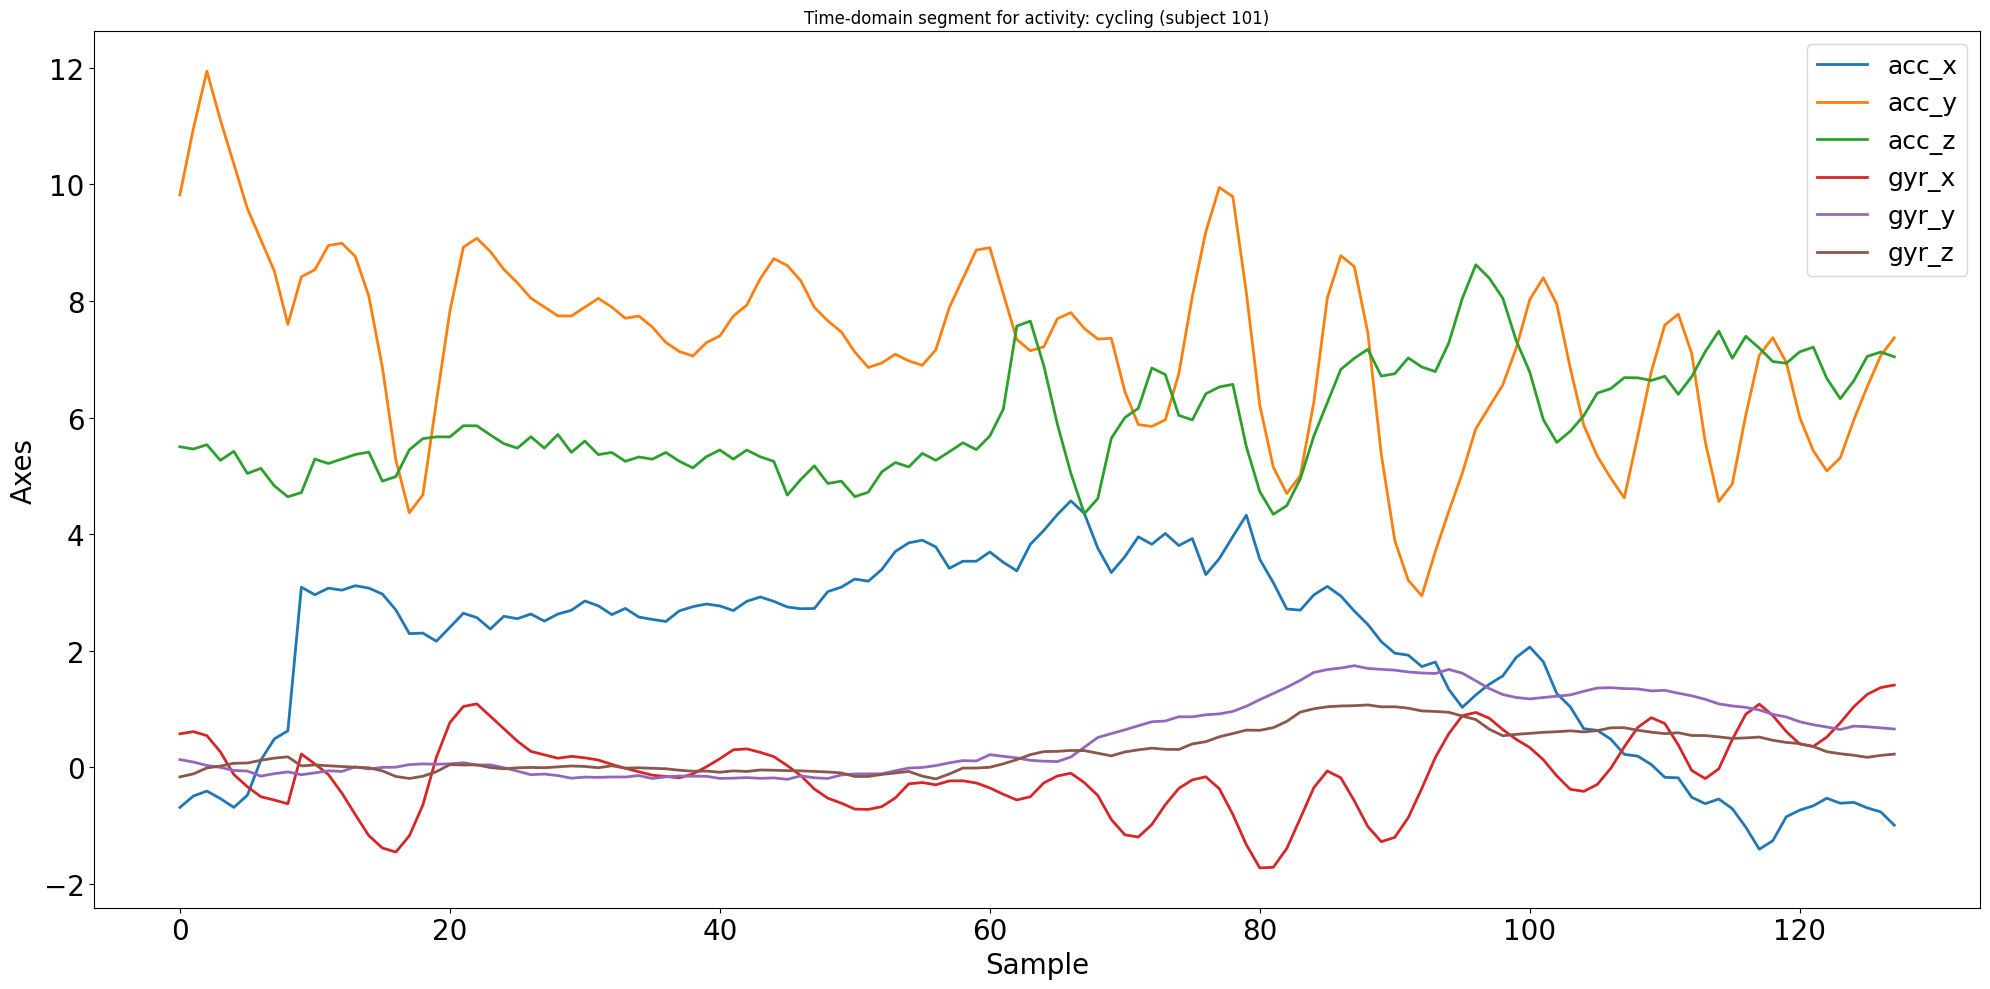

<Figure size 1600x600 with 0 Axes>

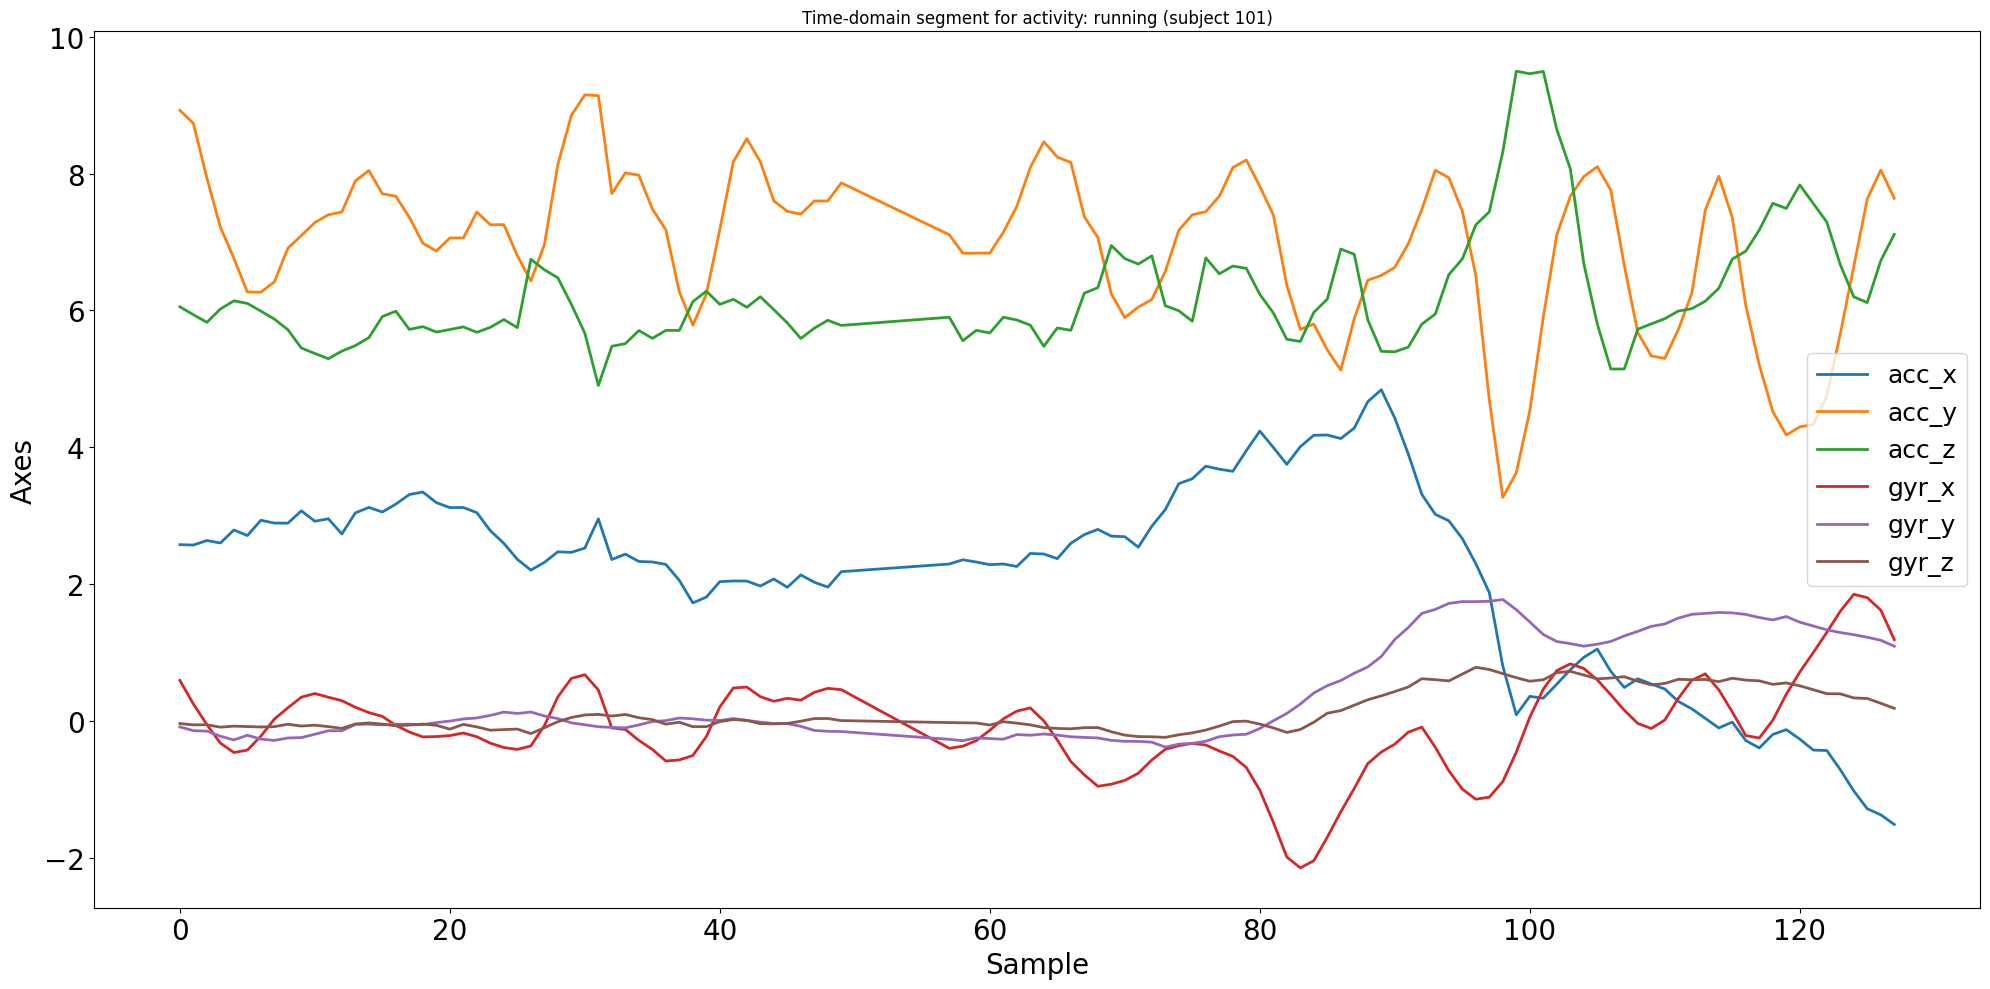

<Figure size 1600x600 with 0 Axes>

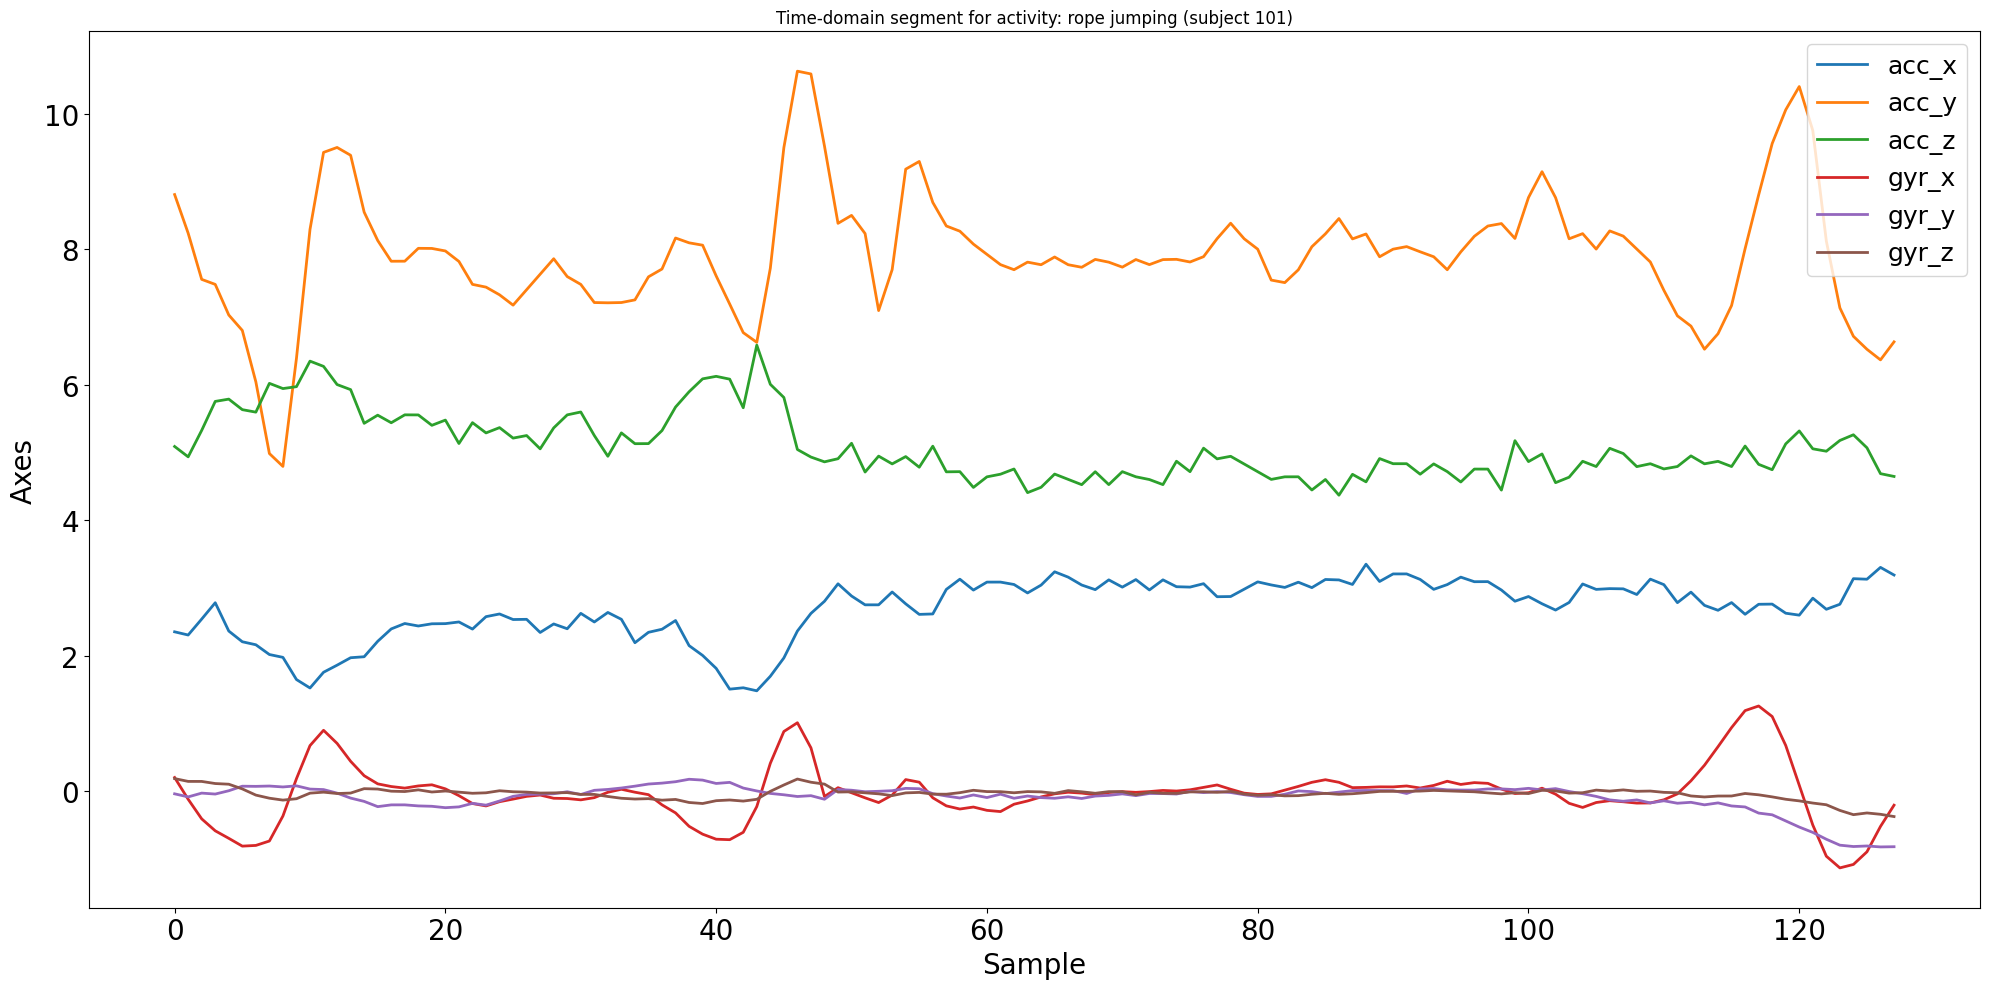

In [202]:
# Time-domain plot of one segment per activity (signal shape)
activity_examples = {}
for doc in documents:
    label = doc["activity_label"]
    # Store the first example for each activity label
    if label not in activity_examples:
        activity_examples[label] = doc
    # Stop once we have one example for each unique activity label
    if len(activity_examples) == segments_df["activity_label"].nunique():
        break

for activity_label, doc in activity_examples.items():
    plt.figure(figsize=(16, 6))
    plot_instance_time_domain(pd.DataFrame(doc["data"]))
    plt.title(f"Time-domain segment for activity: {activity_label} (subject {doc['subject']})")
    plt.tight_layout()

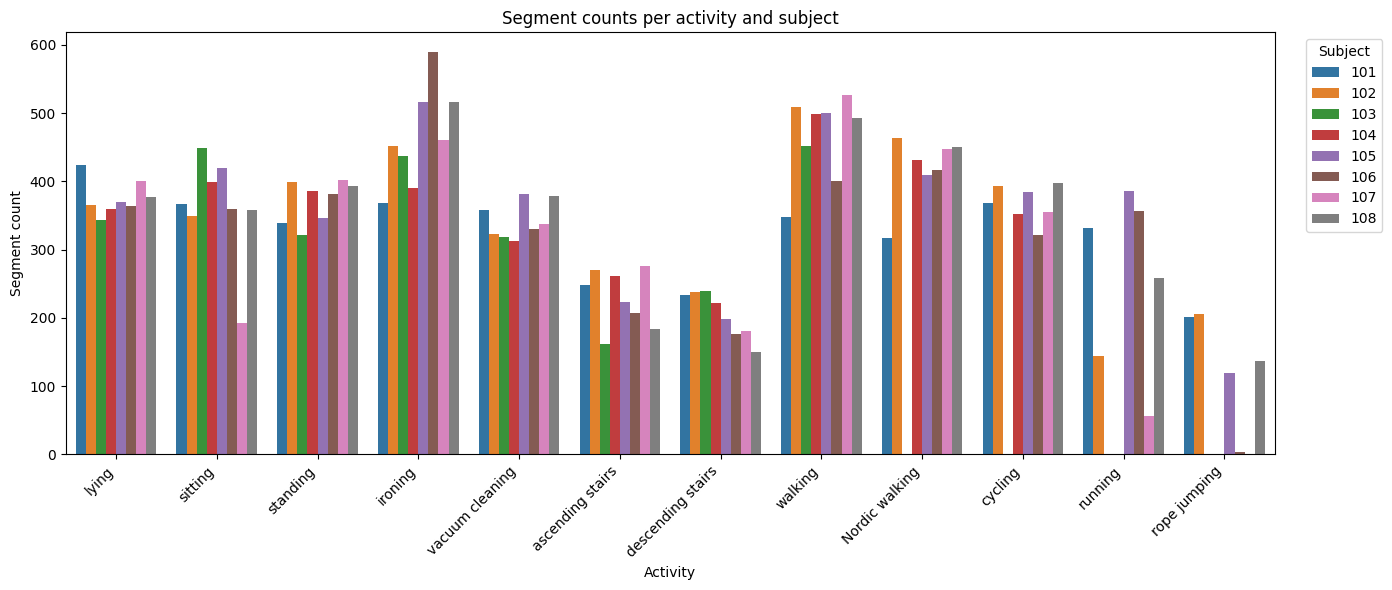

In [203]:
# Segment counts per activity and subject

plt.figure(figsize=(14, 6))
sns.countplot(data=segments_df, x="activity_label", hue="subject", palette="tab10")
plt.xticks(rotation=45, ha="right")
plt.title("Segment counts per activity and subject")
plt.ylabel("Segment count")
plt.xlabel("Activity")
plt.legend(title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Data Processing

* Apply the sliding window algorithm to each segment (use `sliding_window_pd` from `utils.py` with the parameters defined in `config.yml`).
* Apply a low-pass Butterworth filter to each window (use `apply_filter` / `filter_instances` from `utils.py`).
* Detect outliers and confirm that no `NaN` values survive from the ingestion step.

Keep `(window, activity_label, subject)` triplets together throughout this section — you need the subject ID for the train/test split.

In [204]:
# Create sliding windows for each segment and store them in a list
window_size = config["sliding_window"]["ws"]
overlap_ratio = config["sliding_window"]["overlap"]
step = int(window_size * overlap_ratio)
if step <= 0:
    step = window_size
print(f"Window size: {window_size}; step size: {step}")

windowed_instances = []

# Create sliding windows for each segment and store them in a list
# tqdm notebook for progress bar
for doc in tqdm_notebook(documents, desc="Creating sliding windows"):
    df_segment = pd.DataFrame(doc["data"])
    windows = sliding_window_pd(
        df_segment,
        ws=window_size,
        overlap=step,
        w_type=config["sliding_window"]["w_type"],
        w_center=config["sliding_window"]["w_center"],
        print_stats=False,
    )
    for window in windows:
        windowed_instances.append({
            "window": window,
            "activity_label": doc["activity_label"],
            "activity_id": doc["activity_id"],
            "subject": doc["subject"],
        })

print(f"Created {len(windowed_instances)} windows from {len(documents)} segments.")

Window size: 128; step size: 64


Creating sliding windows:   0%|          | 0/30244 [00:00<?, ?it/s]

Created 30244 windows from 30244 segments.


In [205]:
# Apply filtering to each window and store the filtered windows in a new list
filtered_windows = filter_instances(
    [item["window"] for item in windowed_instances],
    order=config["filter"]["order"],
    wn=config["filter"]["wn"],
    filter_type=config["filter"]["type"],
)

# Combine filtered windows with their corresponding labels and subjects into a new list of instances
filtered_instances = [
    {
        "window": filtered_windows[i],
        "activity_label": windowed_instances[i]["activity_label"],
        "activity_id": windowed_instances[i]["activity_id"],
        "subject": windowed_instances[i]["subject"],
    }
    for i in range(len(filtered_windows))
]
print(f"Filtered {len(filtered_instances)} windows.")

Number of filtered instances in the list: 30244
Filtered 30244 windows.


In [206]:
# Check for NaN values in the filtered windows
nan_after_filter = [inst["window"].isna().sum().sum() for inst in filtered_instances]
print("NaN values per filtered window (sample):", nan_after_filter[:10])
assert not any(nan_after_filter), "There are NaN values after filtering!"

processed_instances = pd.DataFrame([
    {
        "activity_label": inst["activity_label"],
        "activity_id": inst["activity_id"],
        "subject": inst["subject"],
        "window": inst["window"],
    }
    for inst in filtered_instances
])
print(processed_instances.shape)

NaN values per filtered window (sample): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(30244, 4)


## Train/Test split

The split must be **by subject**: 6–7 subjects in train, 2–3 in test, with **no overlap**. This forces the model to generalize to users it has never seen, which is the realistic deployment scenario.

Do **not** use `train_test_split` with random shuffling — that would leak windows from the same subject into both sets and inflate the reported metrics.

In [207]:
# Train-test split by subject 

X_train, y_train = [], []
X_test, y_test = [], []


In [208]:
TRAIN_SUBJECTS = ["101", "102", "103", "104", "105", "107"]
TEST_SUBJECTS  = ["106", "108", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

In [209]:
# Iterate through the processed instances and split them into training and test sets based on the subject ID
for idx, inst in processed_instances.iterrows():

    subject = inst["subject"]
    window = inst["window"]

    # Flatten the window into a single feature vector for scaler / classifier input
    features = window.to_numpy().flatten()

    # Label is the activity_id, which is a numeric code for the activity type
    label = inst["activity_id"]

    if subject in TRAIN_SUBJECTS:
        X_train.append(features)
        y_train.append(label)
    elif subject in TEST_SUBJECTS:
        X_test.append(features)
        y_test.append(label)
    else:
        print(f"Subject {subject} not in train or test lists, skipping.")

if len(X_train) > 0:
    X_train = np.vstack(X_train)
if len(X_test) > 0:
    X_test = np.vstack(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

## Scaling

Fit the scaler on the training subjects only, then apply it to the test subjects.

In [210]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [211]:
# Scaling the features using StandardScaler (zero mean, unit variance)
scaler = StandardScaler()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Fit the scaler on the training data and transform both training and test data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Scaled feature shape: {X_train.shape}")

X_train shape: (22244, 768)
X_test shape: (8000, 768)
Scaled feature shape: (22244, 768)


## Dimensionality Reduction (PCA)

Apply PCA to reduce the feature dimensionality while retaining most of the variance. This is especially useful for high-dimensional windowed sensor data.



In [212]:
from sklearn.decomposition import PCA

# Apply PCA with 95% variance retention (or adjust n_components based on your analysis)
n_components = config["PCA"]["n_comp"]  

print(f"\nApplying PCA with {n_components} components (95% variance retention)...")

pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data only (avoid data leakage)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"PCA-reduced feature shape: {X_train_pca.shape}")
print(f"Dimensionality reduction: {X_train.shape[1]} → {X_train_pca.shape[1]} features ({100*X_train_pca.shape[1]/X_train.shape[1]:.1f}%)")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")



Applying PCA with 0.95 components (95% variance retention)...
PCA-reduced feature shape: (22244, 55)
Dimensionality reduction: 768 → 55 features (7.2%)
Variance retained: 0.9501


Original feature dimension: 768
Components to retain 85% variance: 27
Components to retain 95% variance: 55
Variance retained with 55 components: 0.9501


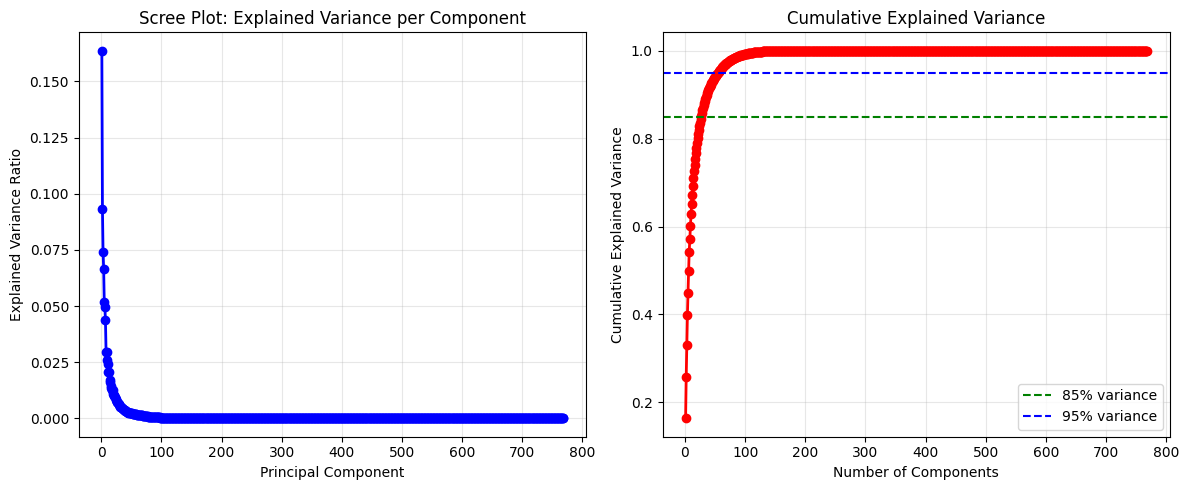

In [213]:
from sklearn.decomposition import PCA

# Analyze explained variance with all components
pca_full = PCA()
pca_full.fit(X_train)

# Cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'bo-', linewidth=2)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot: Explained Variance per Component")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2)
plt.axhline(y=0.85, color='g', linestyle='--', label='85% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Determine optimal number of components to retain 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_85 = np.argmax(cumsum_var >= 0.85) + 1

print(f"Original feature dimension: {X_train.shape[1]}")
print(f"Components to retain 85% variance: {n_components_85}")
print(f"Components to retain 95% variance: {n_components_95}")
print(f"Variance retained with {n_components_95} components: {cumsum_var[n_components_95-1]:.4f}")


### Apply simple classifier

In [214]:
# Use PCA-reduced features
print(f"Using PCA-Reduced Features: {X_train_pca.shape[1]} features")

Using PCA-Reduced Features: 55 features


In [215]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [216]:
# Train classifiers on PCA-reduced features

# Hyperparameters from config for SVC
kernel = config["classifier"]["SVC"]["kernel"]
C = config["classifier"]["SVC"]["C"]
gamma = config["classifier"]["SVC"]["gamma"]
class_weight = config["classifier"]["SVC"].get("class_weight", None)

# Hyperparameters from config for Random Forest
n_estimators = config["classifier"]["RandomForest"]["n_estimators"]
max_depth = config["classifier"]["RandomForest"]["max_depth"]

print("Training on PCA-Reduced Features...")

# SVM classifier
print("Training SVC:")
svm = SVC(kernel=kernel, C=C, gamma=gamma, class_weight=class_weight, random_state=42)
svm.fit(X_train_pca, y_train)

# Random Forest classifier
print("Training Random Forest:")
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
rf.fit(X_train_pca, y_train)


Training on PCA-Reduced Features...
Training SVC:
Training Random Forest:


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Evaluate simple classifier

In [217]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Evaluate PCA-Reduced models
print("\nEVALUATION: PCA-Reduced Models")
print("=" * 60)

results = []

for model_name, model in [("SVC", svm), ("Random Forest", rf)]:
    y_pred = model.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    })

# Summary table
results_df = pd.DataFrame(results)
print("\nSUMMARY TABLE")
print(results_df.to_string(index=False))


EVALUATION: PCA-Reduced Models

SVC:
  Accuracy:  0.5225
  Precision: 0.6806
  Recall:    0.5225
  F1-Score:  0.5242

Random Forest:
  Accuracy:  0.5793
  Precision: 0.6131
  Recall:    0.5793
  F1-Score:  0.5623

SUMMARY TABLE
        Model  Accuracy  Precision  Recall  F1-Score
          SVC   0.52250   0.680576 0.52250  0.524201
Random Forest   0.57925   0.613101 0.57925  0.562255


In [218]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [219]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [220]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [221]:
def run_grid_search(name, model, param_grid, X_train, y_train, cv, verbose):
    print(f"\n GRID SEARCH: {name}\n")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=config["fine_tune"]["grid_search"]["scoring"],
        refit=True,
        cv=cv,
        verbose=verbose,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBEST RESULT")
    print("Params:", grid.best_params_)
    print("F1:", round(grid.best_score_, 4))

    return grid


### Evaluate optimized classifier

Once you are satisfied with the wrist-only configuration, repeat the **load → process → train → evaluate** flow for the chest and ankle IMUs (and combinations thereof) and compare the metrics in your report.

Evaluation of Grid Search results on test set:

 GRID SEARCH: SVC

Fitting 5 folds for each of 6 candidates, totalling 30 fits

BEST RESULT
Params: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
F1: 0.6751

Classification Report for Best SVC Model:
              precision    recall  f1-score   support

           1       0.74      0.93      0.83       741
           2       0.55      0.64      0.59       718
           3       0.69      0.41      0.51       774
           4       0.93      0.44      0.60       894
           5       0.90      0.08      0.14       614
           6       0.52      0.83      0.64       719
           7       0.99      0.46      0.63       868
          12       0.54      0.54      0.54       391
          13       0.33      0.57      0.42       327
          16       0.31      0.76      0.44       709
          17       0.57      0.22      0.32      1105
          24       0.16      0.74      0.26       140

    accuracy          

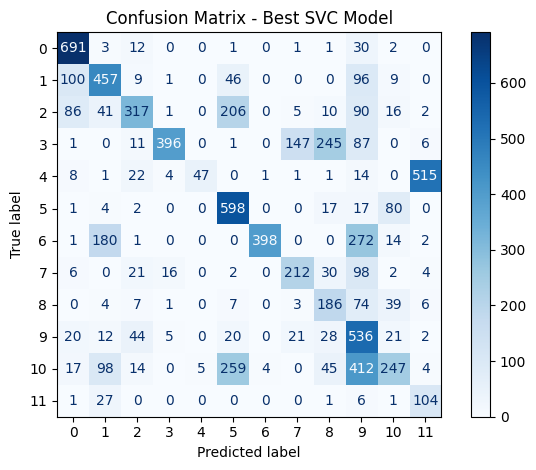


 GRID SEARCH: RandomForest

Fitting 5 folds for each of 24 candidates, totalling 120 fits

BEST RESULT
Params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
F1: 0.6834

Classification Report for Best Random Forest Model:
              precision    recall  f1-score   support

           1       0.87      0.91      0.89       741
           2       0.55      0.74      0.63       718
           3       0.73      0.30      0.43       774
           4       0.78      0.90      0.83       894
           5       1.00      0.71      0.83       614
           6       0.58      0.76      0.66       719
           7       0.96      0.46      0.62       868
          12       0.57      0.40      0.47       391
          13       0.24      0.39      0.30       327
          16       0.32      0.69      0.44       709
          17       0.54      0.36      0.43      1105
          24       0.35   

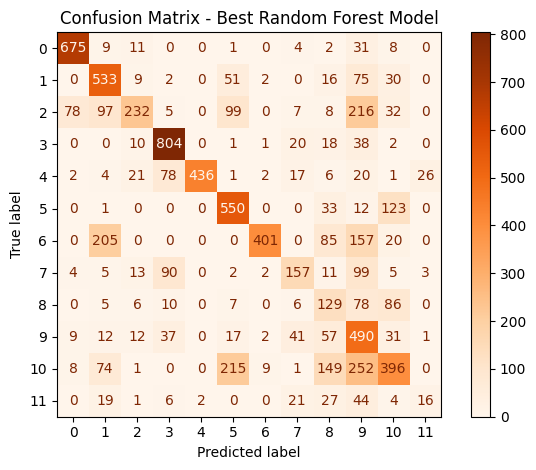

In [222]:
print("Evaluation of Grid Search results on test set:")

# Use the best estimator from grid search to predict on the test set and evaluate
grid = run_grid_search(
    name="SVC",
    model=SVC(random_state=42),
    param_grid=config["fine_tune"]["SVC"]["param_grid"],
    X_train=X_train_pca,
    y_train=y_train,
    cv=config["fine_tune"]["SVC"]["cv"],
    verbose=config["fine_tune"]["SVC"]["verbose"],
)


# After finding the best hyperparameters from grid search, we can evaluate the best SVC model on the test set
best_svc = SVC(**grid.best_params_, random_state=42)
best_svc.fit(X_train_pca, y_train)
y_pred_svc = best_svc.predict(X_test_pca)

# Classification report for the best SVC model
print("\nClassification Report for Best SVC Model:")
print(classification_report(y_test, y_pred_svc, zero_division=0))

# Confusion matrix ( no plotting, just the matrix values)
cm_svc = confusion_matrix(y_test, y_pred_svc)
print("Confusion Matrix for Best SVC Model:")
print(cm_svc)


# Confusion matrix for the best SVC model
cm_svc = confusion_matrix(y_test, y_pred_svc)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc)
disp_svc.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Best SVC Model")
plt.tight_layout()
plt.show()


# Random Forest Grid Search

grid = run_grid_search(
    name="RandomForest",
    model=RandomForestClassifier(random_state=42),
    param_grid=config["fine_tune"]["RandomForest"]["param_grid"],
    X_train=X_train_pca,
    y_train=y_train,
    cv=config["fine_tune"]["RandomForest"]["cv"],
    verbose=config["fine_tune"]["RandomForest"]["verbose"],
)

best_rf = RandomForestClassifier(**grid.best_params_, random_state=42)
best_rf.fit(X_train_pca, y_train)
y_pred_rf = best_rf.predict(X_test_pca)

# Classification report for the best Random Forest model
print("\nClassification Report for Best Random Forest Model:")
print(classification_report(y_test, y_pred_rf, zero_division=0))  

# Confusion matrix ( no plotting, just the matrix values)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for Best Random Forest Model:")
print(cm_rf)

# Confusion matrix for the best Random Forest model
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Best Random Forest Model")
plt.tight_layout()
plt.show()


